Imports

In [49]:
%pip install -q matplotlib seaborn xgboost scikit-learn pandas numpy


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

Create dataframe and initialize X and Y

In [51]:
path = "data/modeling_dataset.csv"

base_dir = os.path.dirname(os.path.abspath(os.getcwd()))

df = pd.read_csv(os.path.join(base_dir, path))

X = df.drop(columns=["fantasy_points"])

# bucket points into 4 tiers                                                                    
y = pd.cut(df["fantasy_points"].clip(lower=0),                                                                                                                                                        
            bins=[-1, 1, 4, 8, 100],           
            labels=[0, 1, 2, 3]).astype(int)       

Print first 5 rows to see some data

In [52]:
df.head(5)

,player,team,opponent,home_away,fantasy_position,season,matchday,date,fantasy_points_prev,fantasy_points_last3_avg,...,pens_made_last3_avg,pens_made_last5_avg,pens_att_prev,pens_att_last3_avg,pens_att_last5_avg,played_prev,played_60_prev,minutes_last3_sum,regular_recently,fantasy_points
0,Aaron Anselmino,Dortmund de,es Villarreal,home,DEF,2025-2026,10,2025-11-25,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1,0,6.0,0,9
1,Aaron Anselmino,Dortmund de,no Bodø/Glimt,home,DEF,2025-2026,13,2025-12-10,9.0,4.5,...,0.0,0.0,0.0,0.0,0.0,1,1,96.0,0,1
2,Aaron Bouwman,nl Ajax,Villarreal es,away,DEF,2025-2026,14,2026-01-20,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1,1,90.0,0,1
3,Aaron Mooy,Celtic sct,de RB Leipzig,home,MID,2022-2023,7,2022-10-11,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1,0,23.0,0,1
4,Aaron Mooy,Celtic sct,ua Shakhtar Donetsk,home,MID,2022-2023,9,2022-10-25,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1,0,48.0,0,1


Display X and y

In [53]:
X.head(5)

,player,team,opponent,home_away,fantasy_position,season,matchday,date,fantasy_points_prev,fantasy_points_last3_avg,...,pens_made_prev,pens_made_last3_avg,pens_made_last5_avg,pens_att_prev,pens_att_last3_avg,pens_att_last5_avg,played_prev,played_60_prev,minutes_last3_sum,regular_recently
0,Aaron Anselmino,Dortmund de,es Villarreal,home,DEF,2025-2026,10,2025-11-25,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,6.0,0
1,Aaron Anselmino,Dortmund de,no Bodø/Glimt,home,DEF,2025-2026,13,2025-12-10,9.0,4.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,96.0,0
2,Aaron Bouwman,nl Ajax,Villarreal es,away,DEF,2025-2026,14,2026-01-20,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,1,90.0,0
3,Aaron Mooy,Celtic sct,de RB Leipzig,home,MID,2022-2023,7,2022-10-11,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,23.0,0
4,Aaron Mooy,Celtic sct,ua Shakhtar Donetsk,home,MID,2022-2023,9,2022-10-25,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,48.0,0


In [54]:
y.head(5)

0    3
1    0
2    0
3    0
4    0
Name: fantasy_points, dtype: int64

Predefine applicable features for each position.

In [55]:
# Each position scores points differently in UCL Fantasy,
# so we train one model per position with only the stats that matter for it.

GENERAL    = ["fantasy_points", "minutes"]
DISCIPLINE = ["yellow_cards", "red_cards", "fouls"]

POSITION_STATS = {
    "GK":  GENERAL + DISCIPLINE + [
        "saves", "penalties_saved", "goals_conceded", "clean_sheet",
    ],
    "DEF": GENERAL + DISCIPLINE + [
        "clean_sheet", "goals_conceded", "tackles", "interceptions", "blocks", "ball_recoveries",
        "goals", "assists", "shots", "shots_on_target", "xg", "npxg", "xag", "sca", "gca", "penalties_won", "pens_made", "pens_att",
    ],
    "MID": GENERAL + DISCIPLINE + [
        "goals", "assists", "shots", "shots_on_target", "xg", "npxg", "xag", "sca", "gca",
        "tackles", "interceptions", "blocks", "ball_recoveries", "clean_sheet", "penalties_won", "pens_made", "pens_att",
    ],
    "FWD": GENERAL + DISCIPLINE + [
        "goals", "assists", "shots", "shots_on_target", "xg", "npxg", "xag", "sca", "gca", "penalties_won", "pens_made", "pens_att",
    ],
}

CONTEXT = ["home_away", "matchday", "regular_recently",
           "minutes_last3_sum", "played_prev", "played_60_prev"]

def expand(bases):
    suffixes = ["_prev", "_last3_avg", "_last5_avg"]
    return [b + s for b in bases for s in suffixes]

df_sorted = df.sort_values("date").reset_index(drop=True)
df_sorted["home_away"] = (df_sorted["home_away"] == "home").astype(int)

y_all = pd.cut(df_sorted["fantasy_points"].clip(lower=0),                                                                                                                                             
            bins=[-1, 1, 4, 8, 100],                  
            labels=[0, 1, 2, 3]).astype(int)                                                                                                                                                       
                                                     

print("Total rows:", len(df_sorted))
print(df_sorted["fantasy_position"].value_counts())

Total rows: 16549
fantasy_position
MID    5949
DEF    5450
FWD    4065
GK     1085
Name: count, dtype: int64


Build train test splits per position

In [56]:
splits = {}

for pos, stat_bases in POSITION_STATS.items():

    mask = df_sorted["fantasy_position"] == pos

    cols = expand(stat_bases) + CONTEXT

    cols = [c for c in cols if c in df_sorted.columns]

    X_pos = df_sorted.loc[mask, cols].astype(float).reset_index(drop=True)

    y_pos = y_all[mask].reset_index(drop=True)

    # 80/20 split
    split = int(len(X_pos) * 0.8)
    
    splits[pos] = (X_pos.iloc[:split], X_pos.iloc[split:],
                   y_pos.iloc[:split], y_pos.iloc[split:])

    print(f"{pos}: train={split}, test={len(X_pos)-split}, features={len(cols)}")


GK: train=868, test=217, features=33
DEF: train=4360, test=1090, features=75
MID: train=4759, test=1190, features=72
FWD: train=3252, test=813, features=57


Train a single LinearRegression on all positions as a baseline to compare against.

In [57]:
X_global = df_sorted[expand(sum(POSITION_STATS.values(), [])) + CONTEXT].copy()                                                                                                                       

X_global = X_global.loc[:, ~X_global.columns.duplicated()]                                                                                                                                            

X_global = X_global[[c for c in X_global.columns if c in df_sorted.columns]].astype(float)                                                                                                            
                                                                                                                                                                                                        

split_g = int(len(X_global) * 0.8)                                                                                                                                                                    

X_train_g, X_test_g = X_global.iloc[:split_g], X_global.iloc[split_g:]                                                                                                                                

y_train_g, y_test_g = y_all.iloc[:split_g], y_all.iloc[split_g:]                                                                                                                                      
                                                        

lr_global = LinearRegression()                                                                                                                                                                        

lr_global.fit(X_train_g, y_train_g)                   

y_pred_g = lr_global.predict(X_test_g)  

In [58]:
print("MAE:", mean_absolute_error(y_test_g, y_pred_g))

print("MSE:", mean_squared_error(y_test_g, y_pred_g))

print("RMSE:", np.sqrt(mean_squared_error(y_test_g, y_pred_g)))

print("R2:", r2_score(y_test_g, y_pred_g))

MAE: 0.6706103902476541
MSE: 0.6584232109967555
RMSE: 0.811432813606127
R2: 0.14402857505594113


Training one XGBoost classifier per position. Goalkeepers get lighter params.

In [59]:
models = {}

for pos, (X_tr, X_te, y_tr, y_te) in splits.items():
    if pos == "GK":
        m = XGBClassifier(objective="multi:softprob", num_class=4,
                n_estimators=150, max_depth=4, learning_rate=0.05,
                random_state=42)
    else:
        m = XGBClassifier(objective="multi:softprob", num_class=4,
                n_estimators=400, max_depth=6, learning_rate=0.05,
                random_state=42)
    m.fit(X_tr, y_tr)
    models[pos] = m

In [60]:
# show accuracy

for pos, m in models.items():
    X_tr, X_te, y_tr, y_te = splits[pos]
    
    pred = m.predict(X_te)
    
    print(f"{pos}")
    
    print(f"accuracy: {accuracy_score(y_te, pred):.3f}")
    
    print(f"baseline (always majority): {y_te.value_counts().max() / len(y_te):.3f}")  
    
    print(f"confusion matrix (rows = actual, cols = predicted):")
    
    print(confusion_matrix(y_te, pred))
    
    print()

GK
accuracy: 0.396
baseline (always majority): 0.410
confusion matrix (rows = actual, cols = predicted):
[[ 0  2  8  0]
 [ 0 30 47  5]
 [ 0 30 56  3]
 [ 0 15 21  0]]

DEF
accuracy: 0.595
baseline (always majority): 0.643
confusion matrix (rows = actual, cols = predicted):
[[615  49  36   1]
 [128  10  17   0]
 [181  14  24   0]
 [ 13   0   2   0]]

MID
accuracy: 0.539
baseline (always majority): 0.499
confusion matrix (rows = actual, cols = predicted):
[[142 249   4   0]
 [ 94 494   5   1]
 [ 24 132   6   0]
 [  3  36   0   0]]

FWD
accuracy: 0.509
baseline (always majority): 0.506
confusion matrix (rows = actual, cols = predicted):
[[324  71  14   2]
 [133  75   9   4]
 [ 86  31  15   3]
 [ 17  19  10   0]]



Feature importance for each position

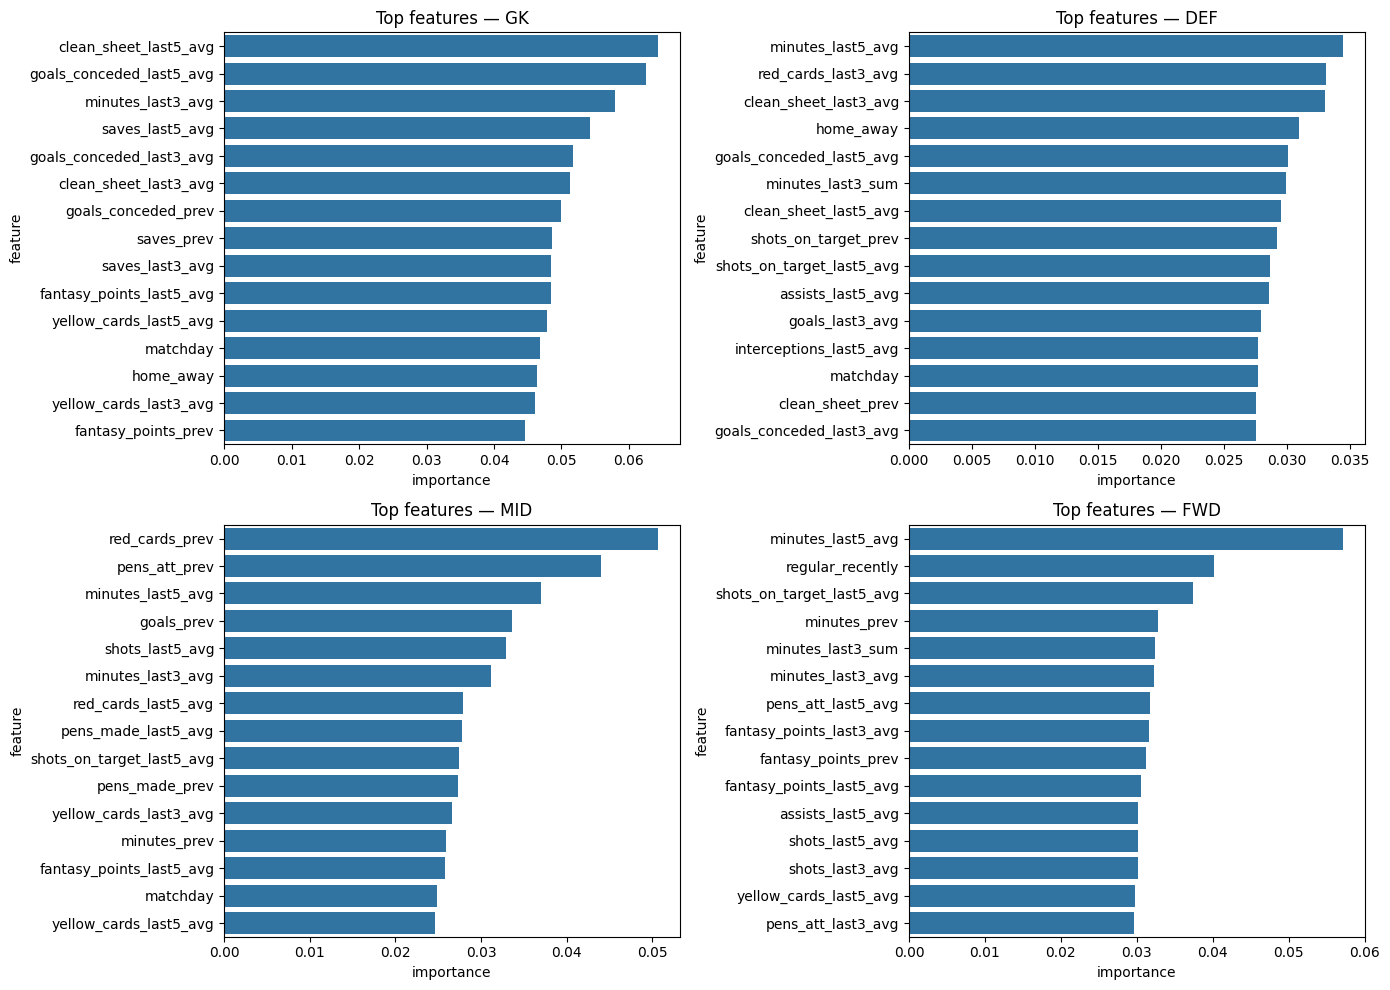

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (pos, m) in zip(axes.flat, models.items()):                                                                                                                                                   
    imp_df = pd.DataFrame({                                                                                                                                                                           
    
        "feature":    splits[pos][0].columns,
        "importance": m.feature_importances_,                                                                                                                                                         
    
    }).sort_values("importance", ascending=False).head(15)                                                                                                                                          
    
    sns.barplot(data=imp_df, x="importance", y="feature", ax=ax)                                                                                                                                      
    
    ax.set_title(f"Top features — {pos}")                                                                                                                                                           

plt.tight_layout()                                                                                                                                                                                    

plt.show()      

In [64]:
# see example predictions 

X_tr, X_te, y_tr, y_te = splits[pos]                                                                                                                                                                  

pred = models[pos].predict(X_te)                                                                                                                                                                      
                                                                                                                                                                                                        
bucket_names = {0: "bench", 1: "ok", 2: "good", 3: "haul"}                                                                                                                                            
                                                                                                                                                                                                        
mask = df_sorted["fantasy_position"] == pos                                                                                                                                                           

df_pos = df_sorted[mask].reset_index(drop=True)                                                                                                                                                       

split_idx = int(len(df_pos) * 0.8)             

df_test = df_pos.iloc[split_idx:].reset_index(drop=True)                                                                                                                                              
                                                          
results = pd.DataFrame({                                                                                                                                                                              
    "player": df_test["player"],
    "opponent": df_test["opponent"],                                                                                                                                                             
    "date": df_test["date"],                                                                                                                                                                 
    "actual_pts": df_test["fantasy_points"],
    "actual_bucket": [bucket_names[b] for b in y_te],                                                                                                                                                 
    "predicted": [bucket_names[b] for b in pred],                                                                                                                                                 
})                                                   

results.sample(20, random_state=1)                     

,player,opponent,date,actual_pts,actual_bucket,predicted
353,Désiré Doué,Athletic Club es,2025-12-10,1,bench,ok
744,Gabriel Jesus,Leverkusen de,2026-03-11,1,bench,bench
537,Mons Bassouamina,cz Slavia Prague,2026-01-28,1,bench,bench
804,Serge Gnabry,it Atalanta,2026-03-18,1,bench,bench
8,Alexander Sørloth,be Union SG,2025-11-04,1,bench,bench
555,Phil Foden,tr Galatasaray,2026-01-28,1,bench,bench
245,Khvicha Kvaratskhelia,eng Tottenham Hotspur,2025-11-26,5,good,good
598,Mika Biereth,fr Paris Saint-Germain,2026-02-17,1,bench,bench
774,Kasper Waarst Høgh,Sporting CP pt,2026-03-17,1,bench,ok
682,Gonzalo García,pt Benfica,2026-02-25,2,ok,bench


In [65]:
# examples where the model predicted a haul
results[results["predicted"] == "haul"].head(20)

,player,opponent,date,actual_pts,actual_bucket,predicted
24,Harry Kane,Paris Saint-Germain fr,2025-11-04,2,ok,haul
88,Anthony Gordon,es Athletic Club,2025-11-05,1,bench,haul
115,Erling Haaland,de Dortmund,2025-11-05,6,good,haul
120,Marcus Thuram,kz FC Kairat,2025-11-05,1,bench,haul
190,Bukayo Saka,de Bayern Munich,2025-11-26,5,good,haul
420,Folarin Balogun,Real Madrid es,2026-01-20,2,ok,haul
429,Anthony Gordon,nl PSV,2026-01-21,6,good,haul
569,Noni Madueke,kz FC Kairat,2026-01-28,2,ok,haul
585,Julián Álvarez,no Bodø/Glimt,2026-01-28,2,ok,haul
